#Random Forest

En este noteboock se utilizará como clasificador random forest y diferentes matrices de características

In [ ]:
import os
import cv2
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, RocCurveDisplay


In [ ]:
#Montar Drive si es necesario
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


##1. Hu + Filtros de Gabor

### 1.1 Creación de la matriz de características

In [ ]:
#Cargar Hu

hu_train = np.load("/content/drive/MyDrive/UNAL/Visión por computador/TareasDigiVision/Clasificación de Imágenes Médicas/results/features/hu_train.npz")
hu_test= np.load("/content/drive/MyDrive/UNAL/Visión por computador/TareasDigiVision/Clasificación de Imágenes Médicas/results/features/hu_test.npz")
hu_val= np.load("/content/drive/MyDrive/UNAL/Visión por computador/TareasDigiVision/Clasificación de Imágenes Médicas/results/features/hu_val.npz")


#Cargar Gabor

gabor_train = np.load("/content/drive/MyDrive/UNAL/Visión por computador/TareasDigiVision/Clasificación de Imágenes Médicas/results/features/gabor_train.npz")
gabor_test= np.load("/content/drive/MyDrive/UNAL/Visión por computador/TareasDigiVision/Clasificación de Imágenes Médicas/results/features/gabor_test.npz")
gabor_val= np.load("/content/drive/MyDrive/UNAL/Visión por computador/TareasDigiVision/Clasificación de Imágenes Médicas/results/features/gabor_val.npz")


In [ ]:
X_hu_train    = hu_train["X"]
X_gabor_train = gabor_train["X"]
y_train       = hu_train["y"]

X_train = np.concatenate([X_gabor_train, X_hu_train], axis=1)

In [ ]:
X_hu_test    = hu_test["X"]
X_gabor_test = gabor_test["X"]
y_test       = hu_test["y"]

X_test = np.concatenate([X_gabor_test, X_hu_test], axis=1)

In [ ]:
X_hu_val    = hu_val["X"]
X_gabor_val = gabor_val["X"]
y_val       = hu_val["y"]

X_val = np.concatenate([X_gabor_val, X_hu_val], axis=1)

In [ ]:
print("Train:", X_train.shape)
print("Val:",   X_val.shape)
print("Test:",  X_test.shape)

Train: (5216, 31)
Val: (16, 31)
Test: (624, 31)


### 1.2 Normalización de features

In [ ]:
scaler = MinMaxScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

### 1.3 Reducción de dimensionalidad

In [ ]:
selector = SelectKBest(score_func=f_classif, k=30)
selector.fit(X_train_scaled, y_train)

X_train_sel = selector.transform(X_train_scaled)
X_val_sel   = selector.transform(X_val_scaled)
X_test_sel  = selector.transform(X_test_scaled)

print(X_train_sel.shape)

(5216, 30)


### 1.4 Random Forest

In [ ]:
#Se genera el cv para entrenamiento y validación


X_tr = np.vstack([X_train_sel, X_val_sel])
y_tr = np.concatenate([y_train, y_val])

print(X_tr.shape, y_tr.shape, X_test_sel.shape, y_test.shape)

(5232, 30) (5232,) (624, 30) (624,)


In [ ]:
from imblearn.ensemble import BalancedRandomForestClassifier
#Se carga el random forest y la validación cruzada


rf = BalancedRandomForestClassifier(
    n_estimators=400,
    class_weight="balanced",
    max_depth=18,
    min_samples_split=4,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

accs, precs, recs, f1s, aucs = [], [], [], [], []

for fold, (idx_tr, idx_val) in enumerate(cv.split(X_tr, y_tr), start=1):
    X_tr_fold, X_val_fold = X_tr[idx_tr], X_tr[idx_val]
    y_tr_fold, y_val_fold = y_tr[idx_tr], y_tr[idx_val]

    rf.fit(X_tr_fold, y_tr_fold)
    y_val_pred  = rf.predict(X_val_fold)
    y_val_proba = rf.predict_proba(X_val_fold)[:, 1]

    accs.append(accuracy_score(y_val_fold, y_val_pred))
    precs.append(precision_score(y_val_fold, y_val_pred))
    recs.append(recall_score(y_val_fold, y_val_pred))
    f1s.append(f1_score(y_val_fold, y_val_pred))
    aucs.append(roc_auc_score(y_val_fold, y_val_proba))

    print(f"Fold {fold}: acc={accs[-1]:.3f}, prec={precs[-1]:.3f}, rec={recs[-1]:.3f}, f1={f1s[-1]:.3f}, auc={aucs[-1]:.3f}")

print("\n=== Promedios CV (10 folds) ===")
print(f"Accuracy : {np.mean(accs):.3f} ± {np.std(accs):.3f}")
print(f"Precision: {np.mean(precs):.3f} ± {np.std(precs):.3f}")
print(f"Recall   : {np.mean(recs):.3f} ± {np.std(recs):.3f}")
print(f"F1-score : {np.mean(f1s):.3f} ± {np.std(f1s):.3f}")
print(f"AUC      : {np.mean(aucs):.3f} ± {np.std(aucs):.3f}")

Fold 1: acc=0.926, prec=0.976, rec=0.923, f1=0.948, auc=0.983
Fold 2: acc=0.910, prec=0.975, rec=0.902, f1=0.937, auc=0.974
Fold 3: acc=0.920, prec=0.955, rec=0.936, f1=0.945, auc=0.974
Fold 4: acc=0.920, prec=0.965, rec=0.925, f1=0.945, auc=0.969
Fold 5: acc=0.910, prec=0.965, rec=0.912, f1=0.938, auc=0.974
Fold 6: acc=0.920, prec=0.955, rec=0.936, f1=0.945, auc=0.968
Fold 7: acc=0.920, prec=0.975, rec=0.915, f1=0.944, auc=0.973
Fold 8: acc=0.931, prec=0.976, rec=0.930, f1=0.953, auc=0.981
Fold 9: acc=0.927, prec=0.961, rec=0.941, f1=0.951, auc=0.974
Fold 10: acc=0.931, prec=0.968, rec=0.938, f1=0.953, auc=0.973

=== Promedios CV (10 folds) ===
Accuracy : 0.921 ± 0.007
Precision: 0.967 ± 0.008
Recall   : 0.926 ± 0.012
F1-score : 0.946 ± 0.005
AUC      : 0.974 ± 0.004


#### 1.4.1 Entrenamiento

In [ ]:
# Entrenamos RF final con TODO X_tr_sel
rf.fit(X_tr, y_tr)


BalancedRandomForestClassifier(class_weight='balanced', max_depth=18,
                               min_samples_leaf=2, min_samples_split=4,
                               n_estimators=400, n_jobs=-1, random_state=42)

### 1.5 Métricas

In [ ]:
y_test_pred  = rf.predict(X_test_sel)
y_test_proba = rf.predict_proba(X_test_sel)[:, 1]

acc  = accuracy_score(y_test, y_test_pred)
prec = precision_score(y_test, y_test_pred)
rec  = recall_score(y_test, y_test_pred)
f1   = f1_score(y_test, y_test_pred)
auc  = roc_auc_score(y_test, y_test_proba)

print("=== Métricas en TEST ===")
print(f"Accuracy : {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall   : {rec:.3f}")
print(f"F1-score : {f1:.3f}")
print(f"AUC      : {auc:.3f}")

print("\nReporte de clasificación:\n")
print(classification_report(y_test, y_test_pred, digits=3))


=== Métricas en TEST ===
Accuracy : 0.712
Precision: 0.695
Recall   : 0.959
F1-score : 0.806
AUC      : 0.804

Reporte de clasificación:

              precision    recall  f1-score   support

           0      0.814     0.299     0.438       234
           1      0.695     0.959     0.806       390

    accuracy                          0.712       624
   macro avg      0.755     0.629     0.622       624
weighted avg      0.740     0.712     0.668       624



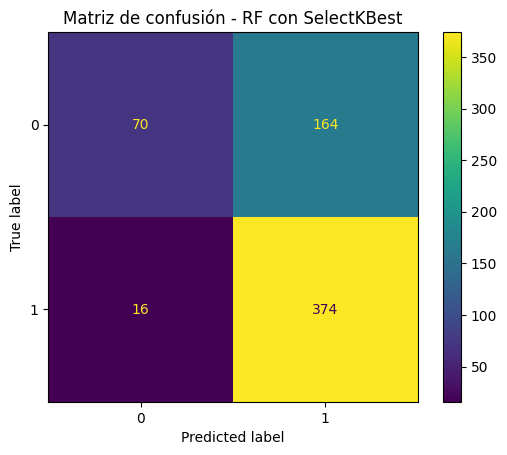

In [ ]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Matriz de confusión - RF con SelectKBest")
plt.show()

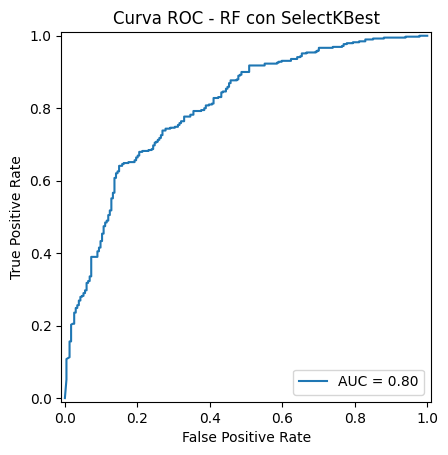

In [ ]:
#Curva ROC y AUC
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)

RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=auc).plot()
plt.title("Curva ROC - RF con SelectKBest")
plt.show()

In [ ]:
#Importancia
importances = rf.feature_importances_
idx_sorted = np.argsort(importances)[::-1]

print("Top 10 features (en el espacio reducido):")
for i in idx_sorted[:10]:
    print(f"Feature reducida {i} -> importancia {importances[i]:.4f}")


Top 10 features (en el espacio reducido):
Feature reducida 28 -> importancia 0.1387
Feature reducida 10 -> importancia 0.0762
Feature reducida 14 -> importancia 0.0755
Feature reducida 12 -> importancia 0.0673
Feature reducida 27 -> importancia 0.0491
Feature reducida 24 -> importancia 0.0485
Feature reducida 19 -> importancia 0.0427
Feature reducida 11 -> importancia 0.0418
Feature reducida 15 -> importancia 0.0397
Feature reducida 20 -> importancia 0.0297


In [ ]:
mask = selector.get_support()            # booleano
orig_indices = np.where(mask)[0]         # índices originales seleccionados
top_orig = orig_indices[idx_sorted[:10]] # features originales

print("\nTop 10 features originales más importantes:")
for orig_idx, imp in zip(top_orig, importances[idx_sorted[:10]]):
    print(f"Feature original {orig_idx} -> importancia {imp:.4f}")



Top 10 features originales más importantes:
Feature original 29 -> importancia 0.1387
Feature original 11 -> importancia 0.0762
Feature original 15 -> importancia 0.0755
Feature original 13 -> importancia 0.0673
Feature original 28 -> importancia 0.0491
Feature original 25 -> importancia 0.0485
Feature original 20 -> importancia 0.0427
Feature original 12 -> importancia 0.0418
Feature original 16 -> importancia 0.0397
Feature original 21 -> importancia 0.0297


## Prueba con Smote

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier

accs_smote, precs_smote, recs_smote, f1s_smote, aucs_smote = [], [], [], [], []

for train_idx, val_idx in cv.split(X_tr, y_tr):
    X_fold_train, X_fold_val = X_tr[train_idx], X_tr[val_idx]
    y_fold_train, y_fold_val = y_tr[train_idx], y_tr[val_idx]

    # Aplicar SMOTE SOLO al train del fold
    sm = SMOTE()
    X_res, y_res = sm.fit_resample(X_fold_train, y_fold_train)

    rf = RandomForestClassifier(
        n_estimators=400,
        max_depth=18,
        min_samples_leaf=2,
        min_samples_split=4,
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X_res, y_res)
    y_pred = rf.predict(X_fold_val)
    y_proba = rf.predict_proba(X_fold_val)[:,1]

    accs_smote.append(accuracy_score(y_fold_val, y_pred))
    precs_smote.append(precision_score(y_fold_val, y_pred))
    recs_smote.append(recall_score(y_fold_val, y_pred))
    f1s_smote.append(f1_score(y_fold_val, y_pred))
    aucs_smote.append(roc_auc_score(y_fold_val, y_proba))

print("\n=== SMOTE + RF (10-fold CV) ===")
print(f"Accuracy : {np.mean(accs_smote):.3f}")
print(f"Precision: {np.mean(precs_smote):.3f}")
print(f"Recall   : {np.mean(recs_smote):.3f}")
print(f"F1-score : {np.mean(f1s_smote):.3f}")
print(f"AUC      : {np.mean(aucs_smote):.3f}")



=== SMOTE + RF (10-fold CV) ===
Accuracy : 0.927
Precision: 0.958
Recall   : 0.944
F1-score : 0.950
AUC      : 0.975


In [ ]:
sm = SMOTE()
X_res, y_res = sm.fit_resample(X_tr, y_tr)

rf_final = RandomForestClassifier(
    n_estimators=400,
    max_depth=18,
    min_samples_leaf=2,
    min_samples_split=4,
    random_state=42,
    n_jobs=-1
)

rf_final.fit(X_res, y_res)

y_test_pred = rf_final.predict(X_test_sel)
y_test_proba = rf_final.predict_proba(X_test_sel)[:,1]


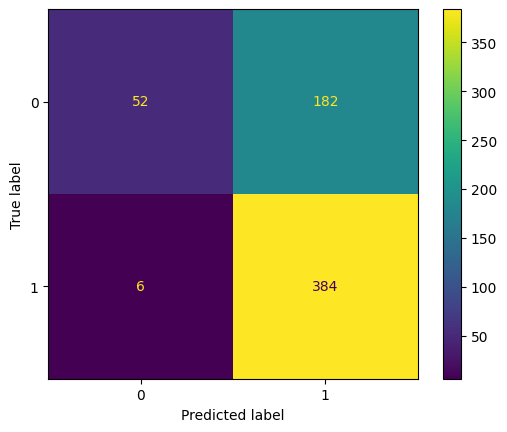

In [ ]:
# Matriz de confusión
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred)
plt.show()



## 2. Fourier + GLCM

### 2.1 Creación de la matriz de características


In [ ]:
#Cargar Fourier

fourier_train = np.load("/content/drive/MyDrive/UNAL/Visión por computador/TareasDigiVision/Clasificación de Imágenes Médicas/results/features/fourier_train.npz")
fourier_test= np.load("/content/drive/MyDrive/UNAL/Visión por computador/TareasDigiVision/Clasificación de Imágenes Médicas/results/features/fourier_test.npz")
fourier_val= np.load("/content/drive/MyDrive/UNAL/Visión por computador/TareasDigiVision/Clasificación de Imágenes Médicas/results/features/fourier_val.npz")


#Cargar GLCM

glcm_train = np.load("/content/drive/MyDrive/UNAL/Visión por computador/TareasDigiVision/Clasificación de Imágenes Médicas/results/features/glcm_merged_train.npz")
glcm_test= np.load("/content/drive/MyDrive/UNAL/Visión por computador/TareasDigiVision/Clasificación de Imágenes Médicas/results/features/glcm_merged_test.npz")
glcm_val= np.load("/content/drive/MyDrive/UNAL/Visión por computador/TareasDigiVision/Clasificación de Imágenes Médicas/results/features/glcm_merged_val.npz")

In [ ]:
#Creación train
X_fourier_train    = fourier_train["X"]
X_glcm_train = glcm_train["X"]
y_train       = fourier_train["y"]

X_train = np.concatenate([X_glcm_train, X_fourier_train], axis=1)

#Creación de test
X_fourier_test    = fourier_test["X"]
X_glcm_test = glcm_test["X"]
y_test       = fourier_test["y"]

X_test = np.concatenate([X_glcm_test, X_fourier_test], axis=1)

#Creación de val
X_fourier_val    = fourier_val["X"]
X_glcm_val = glcm_val["X"]
y_val       = fourier_val["y"]

X_val = np.concatenate([X_glcm_val, X_fourier_val], axis=1)

print("Train:", X_train.shape)
print("Val:",   X_val.shape)
print("Test:",  X_test.shape)

Train: (5216, 68)
Val: (16, 68)
Test: (624, 68)


### 2.2 Normalización de features

In [ ]:
scaler = MinMaxScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

### 1.3 Reducción de dimensionalidad

In [ ]:
selector = SelectKBest(score_func=f_classif, k=60)
selector.fit(X_train_scaled, y_train)

X_train_sel = selector.transform(X_train_scaled)
X_val_sel   = selector.transform(X_val_scaled)
X_test_sel  = selector.transform(X_test_scaled)

print(X_train_sel.shape)

(5216, 60)


### 2.4 Random Forest

In [ ]:
#Se genera el cv para entrenamiento y validación


X_tr = np.vstack([X_train_sel, X_val_sel])
y_tr = np.concatenate([y_train, y_val])

print(X_tr.shape, y_tr.shape, X_test_sel.shape, y_test.shape)

(5232, 60) (5232,) (624, 60) (624,)


In [ ]:
from imblearn.ensemble import BalancedRandomForestClassifier
#Se carga el random forest y la validación cruzada


rf = BalancedRandomForestClassifier(
    n_estimators=400,
    class_weight="balanced",
    max_depth=18,
    min_samples_split=4,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

accs, precs, recs, f1s, aucs = [], [], [], [], []

for fold, (idx_tr, idx_val) in enumerate(cv.split(X_tr, y_tr), start=1):
    X_tr_fold, X_val_fold = X_tr[idx_tr], X_tr[idx_val]
    y_tr_fold, y_val_fold = y_tr[idx_tr], y_tr[idx_val]

    rf.fit(X_tr_fold, y_tr_fold)
    y_val_pred  = rf.predict(X_val_fold)
    y_val_proba = rf.predict_proba(X_val_fold)[:, 1]

    accs.append(accuracy_score(y_val_fold, y_val_pred))
    precs.append(precision_score(y_val_fold, y_val_pred))
    recs.append(recall_score(y_val_fold, y_val_pred))
    f1s.append(f1_score(y_val_fold, y_val_pred))
    aucs.append(roc_auc_score(y_val_fold, y_val_proba))

    print(f"Fold {fold}: acc={accs[-1]:.3f}, prec={precs[-1]:.3f}, rec={recs[-1]:.3f}, f1={f1s[-1]:.3f}, auc={aucs[-1]:.3f}")

print("\n=== Promedios CV (10 folds) ===")
print(f"Accuracy : {np.mean(accs):.3f} ± {np.std(accs):.3f}")
print(f"Precision: {np.mean(precs):.3f} ± {np.std(precs):.3f}")
print(f"Recall   : {np.mean(recs):.3f} ± {np.std(recs):.3f}")
print(f"F1-score : {np.mean(f1s):.3f} ± {np.std(f1s):.3f}")
print(f"AUC      : {np.mean(aucs):.3f} ± {np.std(aucs):.3f}")

Fold 1: acc=0.920, prec=0.981, rec=0.910, f1=0.944, auc=0.983
Fold 2: acc=0.891, prec=0.977, rec=0.874, f1=0.923, auc=0.972
Fold 3: acc=0.922, prec=0.970, rec=0.923, f1=0.946, auc=0.979
Fold 4: acc=0.931, prec=0.971, rec=0.936, f1=0.953, auc=0.961
Fold 5: acc=0.924, prec=0.975, rec=0.920, f1=0.947, auc=0.977
Fold 6: acc=0.916, prec=0.955, rec=0.930, f1=0.943, auc=0.970
Fold 7: acc=0.912, prec=0.975, rec=0.905, f1=0.939, auc=0.967
Fold 8: acc=0.933, prec=0.976, rec=0.933, f1=0.954, auc=0.982
Fold 9: acc=0.897, prec=0.964, rec=0.894, f1=0.928, auc=0.965
Fold 10: acc=0.916, prec=0.965, rec=0.920, f1=0.942, auc=0.972

=== Promedios CV (10 folds) ===
Accuracy : 0.916 ± 0.013
Precision: 0.971 ± 0.007
Recall   : 0.915 ± 0.018
F1-score : 0.942 ± 0.009
AUC      : 0.973 ± 0.007


#### 2.4.1 Entrenamiento

In [ ]:
# Entrenamos RF final con TODO X_tr_sel
rf.fit(X_tr, y_tr)# Entrenamos RF final con TODO X_tr_sel
rf.fit(X_tr, y_tr)

BalancedRandomForestClassifier(class_weight='balanced', max_depth=18,
                               min_samples_leaf=2, min_samples_split=4,
                               n_estimators=400, n_jobs=-1, random_state=42)

### 2.5 Métricas

In [ ]:
y_test_pred  = rf.predict(X_test_sel)
y_test_proba = rf.predict_proba(X_test_sel)[:, 1]

acc  = accuracy_score(y_test, y_test_pred)
prec = precision_score(y_test, y_test_pred)
rec  = recall_score(y_test, y_test_pred)
f1   = f1_score(y_test, y_test_pred)
auc  = roc_auc_score(y_test, y_test_proba)

print("=== Métricas en TEST ===")
print(f"Accuracy : {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall   : {rec:.3f}")
print(f"F1-score : {f1:.3f}")
print(f"AUC      : {auc:.3f}")

print("\nReporte de clasificación:\n")
print(classification_report(y_test, y_test_pred, digits=3))

=== Métricas en TEST ===
Accuracy : 0.760
Precision: 0.747
Recall   : 0.931
F1-score : 0.829
AUC      : 0.853

Reporte de clasificación:

              precision    recall  f1-score   support

           0      0.804     0.474     0.597       234
           1      0.747     0.931     0.829       390

    accuracy                          0.760       624
   macro avg      0.776     0.703     0.713       624
weighted avg      0.768     0.760     0.742       624



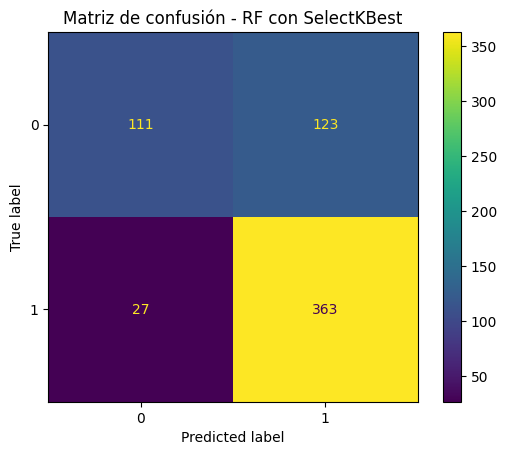

In [ ]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Matriz de confusión - RF con SelectKBest")
plt.show()

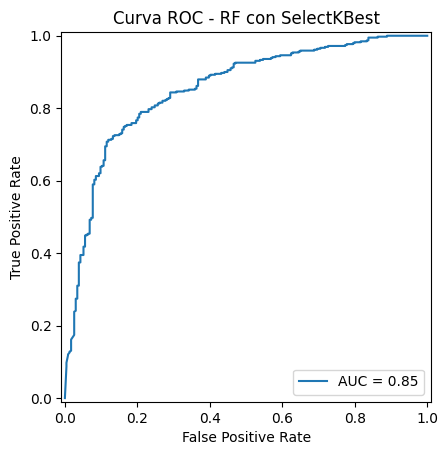

In [ ]:
#Curva ROC y AUC
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)

RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=auc).plot()
plt.title("Curva ROC - RF con SelectKBest")
plt.show()

In [ ]:
#Importancia
importances = rf.feature_importances_
idx_sorted = np.argsort(importances)[::-1]

print("Top 10 features (en el espacio reducido):")
for i in idx_sorted[:10]:
    print(f"Feature reducida {i} -> importancia {importances[i]:.4f}")


Top 10 features (en el espacio reducido):
Feature reducida 19 -> importancia 0.1235
Feature reducida 33 -> importancia 0.1075
Feature reducida 4 -> importancia 0.1015
Feature reducida 45 -> importancia 0.0587
Feature reducida 12 -> importancia 0.0483
Feature reducida 23 -> importancia 0.0397
Feature reducida 27 -> importancia 0.0390
Feature reducida 41 -> importancia 0.0310
Feature reducida 8 -> importancia 0.0301
Feature reducida 37 -> importancia 0.0275


## 2. LBP + Contorno

### 2.1 Creación de la matriz de características


In [ ]:
import numpy as np
import os

# ======================
# 1. Cargar contorno

contour_npz = {
    "train": np.load("/content/drive/MyDrive/UNAL/Visión por computador/TareasDigiVision/Clasificación de Imágenes Médicas/results/features/contour_train.npz", allow_pickle=True),
    "val":   np.load("/content/drive/MyDrive/UNAL/Visión por computador/TareasDigiVision/Clasificación de Imágenes Médicas/results/features/contour_val.npz",   allow_pickle=True),
    "test":  np.load("/content/drive/MyDrive/UNAL/Visión por computador/TareasDigiVision/Clasificación de Imágenes Médicas/results/features/contour_test.npz",  allow_pickle=True),
}

# ======================
# 2. CARGAR LBP NORMAL Y NEUMONÍA
# ======================
lbp_normal_npz = {
    "train": np.load("/content/drive/MyDrive/UNAL/Visión por computador/TareasDigiVision/Clasificación de Imágenes Médicas/results/features/lbp_normal_train.npz", allow_pickle=True),
    "val":   np.load("/content/drive/MyDrive/UNAL/Visión por computador/TareasDigiVision/Clasificación de Imágenes Médicas/results/features/lbp_normal_val.npz",   allow_pickle=True),
    "test":  np.load("/content/drive/MyDrive/UNAL/Visión por computador/TareasDigiVision/Clasificación de Imágenes Médicas/results/features/lbp_normal_test.npz",  allow_pickle=True),
}

lbp_pneu_npz = {
    "train": np.load("/content/drive/MyDrive/UNAL/Visión por computador/TareasDigiVision/Clasificación de Imágenes Médicas/results/features/lbp_pneu_train.npz", allow_pickle=True),
    "val":   np.load("/content/drive/MyDrive/UNAL/Visión por computador/TareasDigiVision/Clasificación de Imágenes Médicas/results/features/lbp_pneu_val.npz",   allow_pickle=True),
    "test":  np.load("/content/drive/MyDrive/UNAL/Visión por computador/TareasDigiVision/Clasificación de Imágenes Médicas/results/features/lbp_pneu_test.npz",  allow_pickle=True),
}


X_data = {}
y_data = {}

splits = ["train", "val", "test"]

for split in splits:
    print(f"\n=== Procesando {split} ===")

    # ---- contorno ----
    cont = contour_npz[split]
    X_cont = cont["X"]
    y_cont = cont["y"]
    files_cont = cont["files"]

    # Normalizar filenames contorno
    files_cont_base = [os.path.basename(f) for f in files_cont]

    # ---- LBP normal ----
    lbp_n = lbp_normal_npz[split]
    X_lbp_n = lbp_n["features"]
    files_n = lbp_n["filenames"]  # ya vienen sin ruta

    # ---- LBP neumonía ----
    lbp_p = lbp_pneu_npz[split]
    X_lbp_p = lbp_p["features"]
    files_p = lbp_p["filenames"]

    # Crear dict filename → vector
    lbp_dict = {}

    for f, x in zip(files_n, X_lbp_n):
        lbp_dict[f] = x

    for f, x in zip(files_p, X_lbp_p):
        lbp_dict[f] = x

    # ---- Alinear al orden de contorno ----
    X_lbp_aligned = []
    missing = []

    for f in files_cont_base:
        if f in lbp_dict:
            X_lbp_aligned.append(lbp_dict[f])
        else:
            missing.append(f)

    X_lbp_aligned = np.array(X_lbp_aligned)
    print("LBP alineado:", X_lbp_aligned.shape)
    print("Missing:", len(missing))

    # ---- Combinar ----
    X_combined = np.concatenate([X_cont, X_lbp_aligned], axis=1)
    y_combined = y_cont.copy()

    X_data[split] = X_combined
    y_data[split] = y_combined

# Final
X_train, y_train = X_data["train"], y_data["train"]
X_val,   y_val   = X_data["val"],   y_data["val"]
X_test,  y_test  = X_data["test"],  y_data["test"]

print("\nTodo listo:")
print("X_train:", X_train.shape)
print("X_val:",   X_val.shape)
print("X_test:",  X_test.shape)



=== Procesando train ===
LBP alineado: (5216, 54)
Missing: 0

=== Procesando val ===
LBP alineado: (16, 54)
Missing: 0

=== Procesando test ===
LBP alineado: (624, 54)
Missing: 0

Todo listo:
X_train: (5216, 58)
X_val: (16, 58)
X_test: (624, 58)


### 2.2 Normalización de features

In [ ]:
scaler = MinMaxScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

### 1.3 Reducción de dimensionalidad

In [ ]:
selector = SelectKBest(score_func=f_classif, k=50)
selector.fit(X_train_scaled, y_train)

X_train_sel = selector.transform(X_train_scaled)
X_val_sel   = selector.transform(X_val_scaled)
X_test_sel  = selector.transform(X_test_scaled)

print(X_train_sel.shape)

(5216, 50)


### 2.4 Random Forest

In [ ]:
#Se genera el cv para entrenamiento y validación


X_tr = np.vstack([X_train_sel, X_val_sel])
y_tr = np.concatenate([y_train, y_val])

print(X_tr.shape, y_tr.shape, X_test_sel.shape, y_test.shape)

(5232, 50) (5232,) (624, 50) (624,)


In [ ]:
from imblearn.ensemble import BalancedRandomForestClassifier
#Se carga el random forest y la validación cruzada


rf = BalancedRandomForestClassifier(
    n_estimators=400,
    class_weight="balanced",
    max_depth=18,
    min_samples_split=4,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

accs, precs, recs, f1s, aucs = [], [], [], [], []

for fold, (idx_tr, idx_val) in enumerate(cv.split(X_tr, y_tr), start=1):
    X_tr_fold, X_val_fold = X_tr[idx_tr], X_tr[idx_val]
    y_tr_fold, y_val_fold = y_tr[idx_tr], y_tr[idx_val]

    rf.fit(X_tr_fold, y_tr_fold)
    y_val_pred  = rf.predict(X_val_fold)
    y_val_proba = rf.predict_proba(X_val_fold)[:, 1]

    accs.append(accuracy_score(y_val_fold, y_val_pred))
    precs.append(precision_score(y_val_fold, y_val_pred))
    recs.append(recall_score(y_val_fold, y_val_pred))
    f1s.append(f1_score(y_val_fold, y_val_pred))
    aucs.append(roc_auc_score(y_val_fold, y_val_proba))

    print(f"Fold {fold}: acc={accs[-1]:.3f}, prec={precs[-1]:.3f}, rec={recs[-1]:.3f}, f1={f1s[-1]:.3f}, auc={aucs[-1]:.3f}")

print("\n=== Promedios CV (10 folds) ===")
print(f"Accuracy : {np.mean(accs):.3f} ± {np.std(accs):.3f}")
print(f"Precision: {np.mean(precs):.3f} ± {np.std(precs):.3f}")
print(f"Recall   : {np.mean(recs):.3f} ± {np.std(recs):.3f}")
print(f"F1-score : {np.mean(f1s):.3f} ± {np.std(f1s):.3f}")
print(f"AUC      : {np.mean(aucs):.3f} ± {np.std(aucs):.3f}")

Fold 1: acc=0.863, prec=0.965, rec=0.846, f1=0.901, auc=0.950
Fold 2: acc=0.884, prec=0.963, rec=0.877, f1=0.918, auc=0.958
Fold 3: acc=0.881, prec=0.953, rec=0.884, f1=0.917, auc=0.947
Fold 4: acc=0.881, prec=0.966, rec=0.871, f1=0.916, auc=0.954
Fold 5: acc=0.864, prec=0.946, rec=0.866, f1=0.904, auc=0.935
Fold 6: acc=0.891, prec=0.944, rec=0.907, f1=0.925, auc=0.950
Fold 7: acc=0.862, prec=0.954, rec=0.856, f1=0.902, auc=0.933
Fold 8: acc=0.897, prec=0.954, rec=0.905, f1=0.929, auc=0.962
Fold 9: acc=0.874, prec=0.942, rec=0.884, f1=0.912, auc=0.944
Fold 10: acc=0.870, prec=0.950, rec=0.871, f1=0.909, auc=0.948

=== Promedios CV (10 folds) ===
Accuracy : 0.877 ± 0.011
Precision: 0.954 ± 0.008
Recall   : 0.877 ± 0.018
F1-score : 0.913 ± 0.009
AUC      : 0.948 ± 0.009


#### 2.4.1 Entrenamiento

In [ ]:
# Entrenamos RF final con TODO X_tr_sel
rf.fit(X_tr, y_tr)# Entrenamos RF final con TODO X_tr_sel
rf.fit(X_tr, y_tr)

BalancedRandomForestClassifier(class_weight='balanced', max_depth=18,
                               min_samples_leaf=2, min_samples_split=4,
                               n_estimators=400, n_jobs=-1, random_state=42)

### 2.5 Métricas

In [ ]:
y_test_pred  = rf.predict(X_test_sel)
y_test_proba = rf.predict_proba(X_test_sel)[:, 1]

acc  = accuracy_score(y_test, y_test_pred)
prec = precision_score(y_test, y_test_pred)
rec  = recall_score(y_test, y_test_pred)
f1   = f1_score(y_test, y_test_pred)
auc  = roc_auc_score(y_test, y_test_proba)

print("=== Métricas en TEST ===")
print(f"Accuracy : {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall   : {rec:.3f}")
print(f"F1-score : {f1:.3f}")
print(f"AUC      : {auc:.3f}")

print("\nReporte de clasificación:\n")
print(classification_report(y_test, y_test_pred, digits=3))

=== Métricas en TEST ===
Accuracy : 0.702
Precision: 0.706
Recall   : 0.897
F1-score : 0.790
AUC      : 0.738

Reporte de clasificación:

              precision    recall  f1-score   support

           0      0.688     0.376     0.486       234
           1      0.706     0.897     0.790       390

    accuracy                          0.702       624
   macro avg      0.697     0.637     0.638       624
weighted avg      0.699     0.702     0.676       624



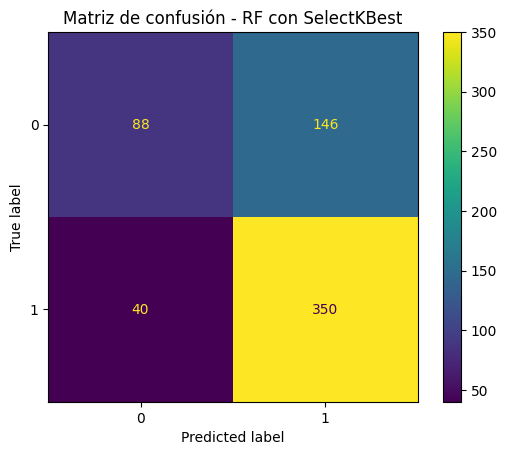

In [ ]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Matriz de confusión - RF con SelectKBest")
plt.show()

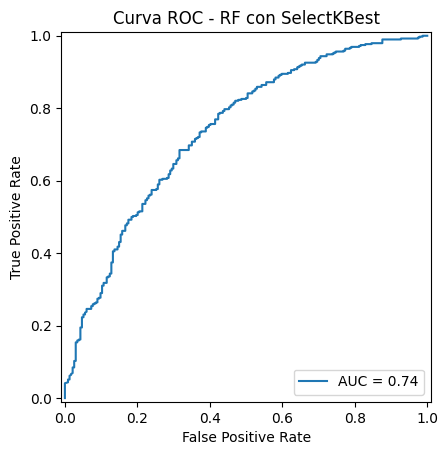

In [ ]:
#Curva ROC y AUC
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)

RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=auc).plot()
plt.title("Curva ROC - RF con SelectKBest")
plt.show()

In [ ]:
#Importancia
importances = rf.feature_importances_
idx_sorted = np.argsort(importances)[::-1]

print("Top 10 features (en el espacio reducido):")
for i in idx_sorted[:10]:
    print(f"Feature reducida {i} -> importancia {importances[i]:.4f}")


Top 10 features (en el espacio reducido):
Feature reducida 3 -> importancia 0.1861
Feature reducida 40 -> importancia 0.0478
Feature reducida 8 -> importancia 0.0470
Feature reducida 41 -> importancia 0.0394
Feature reducida 37 -> importancia 0.0378
Feature reducida 38 -> importancia 0.0356
Feature reducida 1 -> importancia 0.0349
Feature reducida 2 -> importancia 0.0348
Feature reducida 0 -> importancia 0.0334
Feature reducida 42 -> importancia 0.0256
